Code for only running autoencoder bootstrap iteration sweep in Colab -> GCS 
#### changelog 
+ v2- successfully runnig N iterations across all combinations
+ v3- adding WT CLNZ and streamlinecode. created N indepdenent bootstrap run code to evaluate staiblity of results. packaged resample function

In [1]:
!ls 


 autoencoder_cloud_requirements.txt
 autoencoder_train_cloud_v3_paramsweep_only.ipynb
 autoencoder_training_cloud_plot_results_v1.ipynb
 autoencoder_training_cloud_run_v1.ipynb
 autoencoder_training_cloud_v2_w_sweep.ipynb
 autoencoder_training.ipynb
 ax_modifier_functions_cloud.py
 CLAUDE.md
'DB index mean diff cohen_d posthoc test.csv'
 external_functions.py
 LICENSE
 lightning_autoencoder.code-workspace
 paper_plot.mplstyle
 README.md
 sample_data
 service_account_key.json
 sns_plotting_config.py


In [ ]:
# %load_ext autoreload
# %autoreload 2
%pip install -r autoencoder_cloud_requirements.txt
%matplotlib inline
import sys
import os
import logging #to suppress pytorch GPU output etc
import warnings
#supress specific future warnings and automatic lighitning outputs
logging.getLogger("lightning.pytorch.utilities.rank_zero").setLevel(logging.FATAL)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore",r".*does not have many workers which may be a bottleneck.*")
warnings.filterwarnings("ignore",".*GPU available.*",category=UserWarning) # option 2: just filter out the GPU‐warning
#run import modules for analysis 
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
from tqdm import tqdm
import datetime
import pickle
import sklearn
from sklearn.metrics import davies_bouldin_score
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},pandas ver: {pd.__version__}")
#torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
import tensorboard
from functools import partial
from joblib import Parallel, delayed 
#custom loads
from external_functions import *
from sns_plotting_config import *
from ax_modifier_functions_cloud import *
plt.style.use('paper_plot.mplstyle')
#colab kernel fixes 
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Available on Colab
plt.rcParams['font.family'] = 'sans-serif'
## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.4 MB/s eta 0:00:0000:01:00:01
  Installing build dependencies ... done


In [3]:
# # Define the relative path to the src directory
# module_path = r'G:\My Drive\Colab notebooks\Function .py Storage\plot_posthoc_test\src\plot_posthoc_test'
# function_dir =  os.path.join(r'G:\\My Drive\\Colab notebooks\\', 'Function .py Storage')
# print(function_dir)
# if module_path not in sys.path:
#     sys.path.append(module_path)
# if function_dir not in sys.path:
#     sys.path.append(function_dir)
# # Import functions and classes from plot_stat_annotate
# from plot_stat_annotate import *



In [4]:
print(os.getcwd())

/content


## Process Data 


#### Create dataset object for resampling in bootstrapabs

In [5]:
folder_loc = '/Run Outputs/'
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
print(f"date tag: {date_tag}")
folder_name =folder_loc+  f"figure_5_postSVM_decoding_accuracy_and_PCA_plots_"+ date_tag + "/"

date tag: 02_Jan_2026


In [6]:
# new folder structure:
# outputs/                     # For trained models and results
# │   ├── models/                  # Trained model checkpoints
# │   ├── figures/                 # Generated figures
# │   └── logs/                    # Lightning logs
    
data_folder = os.getcwd() +"/data/"
output_folder = os.getcwd() +"/output/"
model_results_folder = output_folder + "/model_results/"
current_run_output = model_results_folder + f"{date_tag}\\"
all_figure_output_folder = output_folder +"/figures/"
fig_output = all_figure_output_folder + f"{date_tag}\\"
#make folders 
make_folder(output_folder)
make_folder(all_figure_output_folder)
make_folder(fig_output)
make_folder(model_results_folder)
make_folder(current_run_output)

'/content/output//model_results/02_Jan_2026\\'

In [7]:
new_trial_df_filename = r"python-made_trial_timeseries_raster_2025-12-21 12.parquet"

In [8]:
#declare loc/names of files to read
load_dataset = True
save_norm_trial_dataset = True
# trial_df_filename = data_folder +  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_df_filename = data_folder +  new_trial_df_filename
if load_dataset:
    print(f"loading_dataset")
    trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()

loading_dataset


,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_RS_Correct,Late_RS,any_enrichment,enriched_in_phase,max_trial_val,mean_rate,active_in_trial,normalization,data_type,date saved
3947,38,cell_95,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-95,3,...,0.0,0.0,1.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3948,38,cell_96,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-96,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3949,38,cell_97,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-97,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3950,38,cell_98,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-98,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12
3951,38,cell_99,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-99,3,...,0.0,0.0,0.0,False,1.0,0.0,False,min_max,raster,2025-12-21 12


In [9]:
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ") #in external_functions.py
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = 'neuron_id', subj_name_col = 'subject_name')#.rename({'neuron_id': "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
subject_stage_info_df.tail()

geno_day
Het CLNZ         840
Het VEH          851
Het postCLNZ     914
WT CLNZ          985
WT VEH          1034
Name: neuron_id, dtype: int64
4624


,subject_name,geno_day,task_phase_vec,neuron_id,num_enriched_units,num_units,trial_num,count_of_trials,over_5
196,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-100, 9_3_HET_RS3-129, 9_3_HET_RS3...",23,171,"[3, 5]",2,"[False, False]"
197,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-124, 9_3_HET_RS3-129, 9_3_HET_RS3...",10,171,"[17, 19, 21]",3,"[True, True, True]"
198,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-128, 9_3_HET_RS3-138, 9_3_HET_RS3...",12,171,"[18, 20]",2,"[True, True]"
199,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-129, 9_3_HET_RS3-138, 9_3_HET_RS3...",16,171,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-130, 9_3_HET_RS3-169, 9_3_HET_RS3...",4,171,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### save class matrix store for loading later

In [10]:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

In [11]:
def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)



# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,'neuron_id')
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,'neuron_id')

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))

Identical: True
Shape match: True
Columns match: True
Index match: True


In [12]:
def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase)
                        current_ppop_draw[dataset] =  horzcat_all_trials(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

In [13]:
from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

lightning_autoencoder_googleID = '1D6Vg0uPWJD4hHEaS4nDtFPNBoWZY2ovN'
# ============ SETUP (run once per session) ============
SCOPES = ['https://www.googleapis.com/auth/drive']
SERVICE_ACCOUNT_FILE = 'service_account_key.json'
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
drive_service = build('drive', 'v3', credentials=creds)
drive_service

In [14]:

def save_to_drive(local_path, drive_filename, folder_id=None):
    """Upload file to Google Drive. Optionally specify a folder ID."""
    if not os.path.exists(local_path):
        print(f"Warning: {local_path} does not exist, skipping upload")
        return None
    metadata = {'name': drive_filename}
    if folder_id:
        metadata['parents'] = [folder_id]
    media = MediaFileUpload(local_path)
    file = drive_service.files().create(body=metadata,
                                        media_body=media,
                                        fields='id',
                                        supportsAllDrives=True).execute()
    # Transfer ownership to your personal account
    drive_service.permissions().create(
        fileId=file_id,
        transferOwnership=True,
        body={'type': 'user', 'role': 'owner',
               'emailAddress': "13carlosj@gmail.com"}).execute()
    print(f"Saved to Drive: {drive_filename}")
    file_id = file.get('id')


    return 

def create_drive_folder(folder_name, parent_id=None):
    metadata = {
        'name': folder_name,
        'mimeType': 'application/vnd.google-apps.folder'
    }
    if parent_id:
        metadata['parents'] = [parent_id]
    folder = drive_service.files().create(body=metadata, fields='id').execute()
    return folder.get('id')

# # In your training loop:
# pd.concat(bootstrap_storage).to_parquet(checkpoint_file)
# save_to_drive(checkpoint_file, f"bootstrap_checkpoint_{date_tag}.parquet")

In [15]:
from google.cloud import storage

client = storage.Client.from_service_account_json('service_account_key.json')
bucket = client.bucket('colab_autoencoder_output')

def save_to_gcs(local_path, blob_name):
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(local_path)
    print(f"Uploaded: gs://colab_autoencoder_output/{blob_name}")

# Test it
save_to_gcs('/content/README.md', 'README.md')

Uploaded: gs://colab_autoencoder_output/README.md


In [16]:
local_colab_folder = os.getcwd() + "/class_matrix_results/"
#make folders 
make_folder(local_colab_folder)

'/content/class_matrix_results/'

In [17]:
# save store class_matrix_store
class_matrix_save_file =  f"pseudopop_ensemble_activity_dict_{date_tag}.pickle"
load_filename = data_folder + f"pseudopopulation_ensemble_activity_store_20_Jun_2025.pickle"

#set options
make_class_matrix = True
save_class_matrix = True
write_to_GCS = True
neuron_ID_col = 'neuron_id'
#set loop
if make_class_matrix: ##create class matrix store
    #extract enrichment to see what subjects had 0 enriched cells 
    neuron_enrichment =  trial_tseries_df_norm.groupby(['subject_name', 'geno_day', 'neuron_id'])[stage_names].mean().reset_index()
    phase_enrichment_by_subj = neuron_enrichment[list(stage_names) + ['subject_name', 'geno_day']].groupby(by = ['subject_name', 'geno_day']).sum().reset_index()
    
    #filter by subjects with > 1 trial in a given stage 
    trial_list_by_dataset= subject_stage_info_df.loc[:,['subject_name', 
                                                        'geno_day', 'task_phase_vec', 'trial_num', 'count_of_trials']]
    trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]##important- threshold to take datasets with >1 trials per section (to have enough variety in neural activity)
    enrich_unit_ID_by_name_df = subject_stage_info_df.loc[:,['subject_name', 'geno_day', 'task_phase_vec', neuron_ID_col]]
    dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['subject_name'].unique().reset_index()
    
    #use premade information to create new matrix
    class_matrix_store = make_dataset_matrix_store_only(stage_names,
                                                        trial_tseries_df_norm,
                                                        unit_ID_col = neuron_ID_col,
                                                        enrich_unit_ID_by_name_df = enrich_unit_ID_by_name_df, 
                                                        numeric_col = numeric_col,
                                                        trial_list_by_dataset = trial_list_by_dataset,
                                                        dataset_name_by_geno_day = dataset_name_by_geno_day,
                                                        phase_enrichment_by_subj = phase_enrichment_by_subj)
    if save_class_matrix:
        print(f"Saving {class_matrix_save_file}")
        with open(local_colab_folder + class_matrix_save_file, 'wb') as handle:
            pickle.dump(class_matrix_store, handle, protocol=pickle.HIGHEST_PROTOCOL)
            if write_to_GCS:
                print(f"Writing to CGS: {class_matrix_save_file}")
                save_to_gcs(local_colab_folder + class_matrix_save_file, local_colab_folder + class_matrix_save_file)
else: #if you don't make or save one, you load one 
    print(f" loading file: {load_filename}")
    with open(load_filename, 'rb') as handle:
        class_matrix_store = pickle.load(handle)

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Saving pseudopop_ensemble_activity_dict_02_Jan_2026.pickle
Writing to CGS: pseudopop_ensemble_activity_dict_02_Jan_2026.pickle
Uploaded: gs://colab_autoencoder_output//content/class_

## Test Pytorch Lightning Autoencoder function on sample data 

#### Define pytorch lightining functions

In [18]:
## separate into function 
def return_train_test_tensorDataset(input_data, input_labels:np.array, shuffle:bool = True, test_on_train:bool = True):
    '''TO- given numpy matrices, and optional shuffle, return 2 pytorch test and train datasets in tensor format'''
    #moved from outside func to inside
    input_data = input_data.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
    #get indices
    assert input_data.shape[0] > 0
    rng = np.random.default_rng()
    n_samples = input_data.shape[0]
    input_data_index =np.arange(0,n_samples) 
    permuted_index = rng.permutation(input_data_index)

    if test_on_train:
        if shuffle:
            train_index = permuted_index
            test_index = permuted_index
        else: #non shuffle, test set = train set
            train_index = input_data_index
            test_index = train_index
    else: #if test not == train
        if shuffle:
            train_index = permuted_index[0:n_samples//2]
            test_index = permuted_index[n_samples//2:n_samples]
        else:
            train_index = input_data_index[0:n_samples//2]
            test_index =  input_data_index[n_samples//2:n_samples]
        
    ##extract data of interest 
    train_data= torch.tensor(input_data[train_index,:], dtype=torch.float32)
    train_labels= torch.tensor(input_labels[train_index], dtype=torch.float32)
    
    test_data = torch.tensor(input_data[test_index,:], dtype=torch.float32)
    test_labels = torch.tensor(input_labels[test_index], dtype=torch.float32)
    ## consolidate into TEnsorDataset objects
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    
    return train_dataset, test_dataset

In [19]:
weight_decay = 1e-2
class dropout_net(nn.Module):
    def __init__(self, layer_1_input=50, bottleneck_input = 9, bottleneck_size = 2,dropout= 0):
        super().__init__()
        ### Using a bottleneck latent dimension of 2
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input,bottleneck_input),nn.Mish(),nn.Dropout(dropout),nn.Linear(bottleneck_input, bottleneck_size)) #from 250 node layer to 3D bottle neck/ latent space 
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size,bottleneck_input),nn.Mish(),nn.Linear(bottleneck_input, layer_1_input))

    def forward(self, x):      
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# define the LightningModule
class LitAutoEncoder(L.LightningModule):
    def __init__(self, dropout_net, **model_kwargs):#load/import  model 
        super().__init__()
        self.save_hyperparameters()# save hyperparameters to self.hparams
        self.model = dropout_net(**model_kwargs)# instantiate your model
        
    def configure_optimizers(self):
        #NEW using  weight decay baked into AdamW
        optimizer = optim.AdamW(self.parameters(),weight_decay = weight_decay, lr=0.0125)### Define your loss function (training criterion). tempw as at 0.0125, reset to 0.013
        return optimizer 
 # training_step of the LightningModule configure how your training routine behaves with a batch of training data:      
    def training_step(self, batch, batch_index):
        (data, target) = batch #unpack traiing data 
        output = self.forward(data) #get reconstruction output of model
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)# logs metrics for each training_step, & the average across the epoch, to the progress bar and logger
        return loss
    
    def forward(self, x):
        # here you define how to get outputs from inputs
        return self.model(x)

    def encode(self, x):
        # directly reach into the wrapped nn.Module
        return self.model.encoder(x)

In [20]:
class LossHistory(L.Callback):
    ## class used to store loss history of trainer module through callbacks to the trainer
    def __init__(self):
        super().__init__()
        self.train_losses = []

    def on_train_epoch_end(self, trainer, pl_module):        # pl_module.log(..., on_epoch=True) ensures 'train_loss' is in callback_metrics
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None: # .item() to turn it into a Python float
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.item())

In [21]:
def lightning_encode(model, test_loader):
    ### Push data into latent space without retreiving
    model.freeze()
    latent =[]
    labels = []
    # device = next(model.parameters()).device
    # print("Model is on:", device)
    for batch_idx, (data, target) in enumerate(test_loader): #target is true labels y
        latentSpace = model.encode(data)
        #store results
        latent.append(latentSpace.detach().numpy())
        labels.append(target.detach().numpy())
    return np.vstack(latent),  np.hstack(labels) # this should match the dim of latent_embeddings, so each pair of coordinates has an associated label

#### Test sample model performance on pytorch lightning

## Hyperparameter Sweep: Activation Functions & Hidden Layer Sizes

Sweep over:
- **Activation functions**: ReLU, Leaky ReLU, Mish
- **Hidden layer sizes**: 2, 3, 4, 5 units

In [22]:
# Flexible autoencoder with configurable activation function
ACTIVATION_MAP = {
    'relu': nn.ReLU,
    'leaky_relu': nn.LeakyReLU,
    'mish': nn.Mish,
}

class FlexibleAutoEncoder(nn.Module):
    """Autoencoder with configurable activation function and hidden layer size."""
    def __init__(self, layer_1_input=50, bottleneck_input=9, bottleneck_size=2, 
                 dropout=0, activation='mish'):
        super().__init__()
        activation_fn = ACTIVATION_MAP.get(activation, nn.Mish)
        
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input, bottleneck_input),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(bottleneck_input, bottleneck_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, bottleneck_input),
            activation_fn(),
            nn.Linear(bottleneck_input, layer_1_input)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


class LitFlexibleAutoEncoder(L.LightningModule):
    """Lightning wrapper for FlexibleAutoEncoder with configurable hyperparameters."""
    def __init__(self, layer_1_input=50, bottleneck_input=9, bottleneck_size=2,
                 dropout=0, activation='mish', lr=0.0125, weight_decay=1e-2):
        super().__init__()
        self.save_hyperparameters()
        self.model = FlexibleAutoEncoder(
            layer_1_input=layer_1_input,
            bottleneck_input=bottleneck_input,
            bottleneck_size=bottleneck_size,
            dropout=dropout,
            activation=activation
        )
        self.lr = lr
        self.weight_decay = weight_decay
        
    def configure_optimizers(self):
        return optim.AdamW(self.parameters(), weight_decay=self.weight_decay, lr=self.lr)
    
    def training_step(self, batch, batch_index):
        data, target = batch
        output = self.forward(data)
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss
    
    def forward(self, x):
        return self.model(x)

    def encode(self, x):
        return self.model.encoder(x)

In [27]:
# Sweep configuration
sweep_config = {'activations': ['relu', 'leaky_relu', 'mish'],
    'hidden_sizes': [2, 3, 4, 5],  # bottleneck_input (hidden layer size)
}

# Fixed parameters for the sweep
comparison = 'Early_IA_Error_v_Early_RS_Error'
ensemble = 'Early_IA_Correct'
n_frames_to_draw = 500
n_epochs = 50
n_bootstrap = 1000  # number of bootstrap iterations per hyperparameter combo
BATCH_SIZE = 500

# Prepare data for the sweep (using first genotype as test case)
geno = geno_order[0]  # 'WT VEH'
class_0, class_1 = comparison.split("_v_")

print(f"Sweep configuration:")
print(f"  Comparison: {comparison}")
print(f"  Ensemble: {ensemble}")
print(f"  Genotype: {geno}")
print(f"  Activations: {sweep_config['activations']}")
print(f"  Hidden sizes: {sweep_config['hidden_sizes']}")
print(f"  Bootstrap iterations: {n_bootstrap}")
print(f"  Total combinations: {len(sweep_config['activations']) * len(sweep_config['hidden_sizes'])}")

Sweep configuration:
  Comparison: Early_IA_Error_v_Early_RS_Error
  Ensemble: Early_IA_Correct
  Genotype: WT VEH
  Activations: ['relu', 'leaky_relu', 'mish']
  Hidden sizes: [2, 3, 4, 5]
  Bootstrap iterations: 1000
  Total combinations: 12


In [28]:
def train_single_sweep_model(n_cells, train_loader, test_loader, 
                              activation, hidden_size, n_epoch=50, dropout=0):
    """Train a single model with given hyperparameters and return DB index."""
    model = LitFlexibleAutoEncoder(
        layer_1_input=n_cells,
        bottleneck_input=hidden_size,
        bottleneck_size=2,
        dropout=dropout,
        activation=activation
    )
    
    history = LossHistory()
    trainer = L.Trainer(
        enable_model_summary=False,
        enable_progress_bar=False,
        accelerator="cpu",
        enable_checkpointing=False,
        max_epochs=n_epoch,
        log_every_n_steps=2,
        callbacks=[history],
    )
    trainer.fit(model, train_loader)
    
    loss = history.train_losses
    model.freeze()
    
    with torch.no_grad():
        embed, labels = lightning_encode(model, test_loader)
    
    db_index = davies_bouldin_score(embed, labels)
    final_loss = loss[-1] if loss else np.nan
    
    return {
        'db_index': db_index,
        'final_loss': final_loss,
        'activation': activation,
        'hidden_size': hidden_size,
    }


def run_sweep_bootstrap(class_matrix_store, ensemble, geno, comparison,
                        activations, hidden_sizes, n_frames_to_draw=500,
                        n_bootstrap=20, n_epoch=50, batch_size=500):
    """Run hyperparameter sweep with bootstrap resampling."""
    class_0, class_1 = comparison.split("_v_")
    sweep_results = []
    
    total_combos = len(activations) * len(hidden_sizes)
    print(f"Running sweep: {total_combos} combinations x {n_bootstrap} bootstrap = {total_combos * n_bootstrap} total runs")
    
    for activation in activations:
        for hidden_size in hidden_sizes:
            print(f"Testing: activation={activation}, hidden_size={hidden_size}")
            
            for b in tqdm(range(n_bootstrap), desc=f"{activation}/{hidden_size}", leave=False):
                # Resample data for this bootstrap iteration
                ensemble_resample = resample_ensemble_stage_activity(
                    class_matrix_store, n_frames_to_draw, ensemble, geno,
                    stages_to_resample=[class_0, class_1]
                )
                
                concat_matrix, concat_labels = fast_pack_data_local(
                    ensemble_resample[class_0], ensemble_resample[class_1], 0, 1
                )
                
                train_dataset, test_dataset = return_train_test_tensorDataset(
                    concat_matrix, concat_labels, shuffle=True
                )
                
                n_cells = concat_matrix.shape[0]
                train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                                         shuffle=False, num_workers=0)
                test_loader = DataLoader(test_dataset, batch_size=batch_size,
                                        shuffle=False, num_workers=0)
                
                # Train model and get results
                result = train_single_sweep_model(
                    n_cells, train_loader, test_loader,
                    activation, hidden_size, n_epoch=n_epoch
                )
                result['bootstrap_iter'] = b
                result['ensemble'] = ensemble
                result['geno'] = geno
                result['comparison'] = comparison
                sweep_results.append(result)
    
    return pd.DataFrame(sweep_results)

In [ ]:
import glob
from pathlib import Path

def find_sweep_parquet_files(search_dirs=None):
    """Find all sweep result parquet files and return sorted by modification time."""
    if search_dirs is None:
        # Default search locations
        search_dirs = [
            csv_folder_current_run if 'csv_folder_current_run' in dir() else '',
            csv_folder_most_recent if 'csv_folder_most_recent' in dir() else '',
            'output/model_results/',
            '.',
        ]
    
    sweep_files = []
    for search_dir in search_dirs:
        if search_dir and os.path.exists(search_dir):
            pattern = os.path.join(search_dir, '**/sweep_results*.parquet')
            found = glob.glob(pattern, recursive=True)
            sweep_files.extend(found)
    
    # Remove duplicates and sort by modification time (newest first)
    sweep_files = list(set(sweep_files))
    sweep_files.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    return sweep_files

def load_latest_sweep_results(search_dirs=None, verbose=True):
    """Find and load the most recently created sweep results parquet file."""
    sweep_files = find_sweep_parquet_files(search_dirs)
    
    if not sweep_files:
        print("No sweep result files found.")
        return None, None
    
    if verbose:
        print(f"Found {len(sweep_files)} sweep result file(s):")
        for i, f in enumerate(sweep_files):
            mtime = datetime.fromtimestamp(os.path.getmtime(f))
            size_kb = os.path.getsize(f) / 1024
            print(f"  [{i}] {Path(f).name} ({size_kb:.1f} KB, modified: {mtime.strftime('%Y-%m-%d %H:%M')})")
    
    latest_file = sweep_files[0]
    if verbose:
        print(f"\nLoading latest: {latest_file}")
    
    df = pd.read_parquet(latest_file)
    return df, latest_file

In [ ]:
load_sweep_df = True
if load_sweep_df:
    # Detect and load the most recent sweep results
    sweep_results_df, loaded_file = load_latest_sweep_results()
    if sweep_results_df is not None:
        print(f"\nLoaded {len(sweep_results_df)} rows from sweep results")
        print(f"Columns: {list(sweep_results_df.columns)}")
        print(f"\nUnique configurations tested:")
        print(f"  Activations: {sweep_results_df['activation'].unique().tolist()}")
        print(f"  Hidden sizes: {sweep_results_df['hidden_size'].unique().tolist()}")
else:
    # Run the hyperparameter sweep
    sweep_results_df = run_sweep_bootstrap(
        class_matrix_store=class_matrix_store,
        ensemble=ensemble,
        geno=geno,
        comparison=comparison,
        activations=sweep_config['activations'],
        hidden_sizes=sweep_config['hidden_sizes'],
        n_frames_to_draw=n_frames_to_draw,
        n_bootstrap=n_bootstrap,
        n_epoch=n_epochs,
        batch_size=BATCH_SIZE
    )

    # Save results to colab + GCS
    sweep_filename = f"sweep_results_{comparison}_{ensemble}_{geno.replace(' ','_')}.parquet"   
    sweep_results_df.to_parquet(f"/content/{sweep_filename}")
    save_to_gcs(f"/content/{sweep_filename}", f"/content/NN_param_sweep_{date_tag}/{sweep_filename}")

    print(f"\nSweep complete! Results saved.")
sweep_results_df.head()

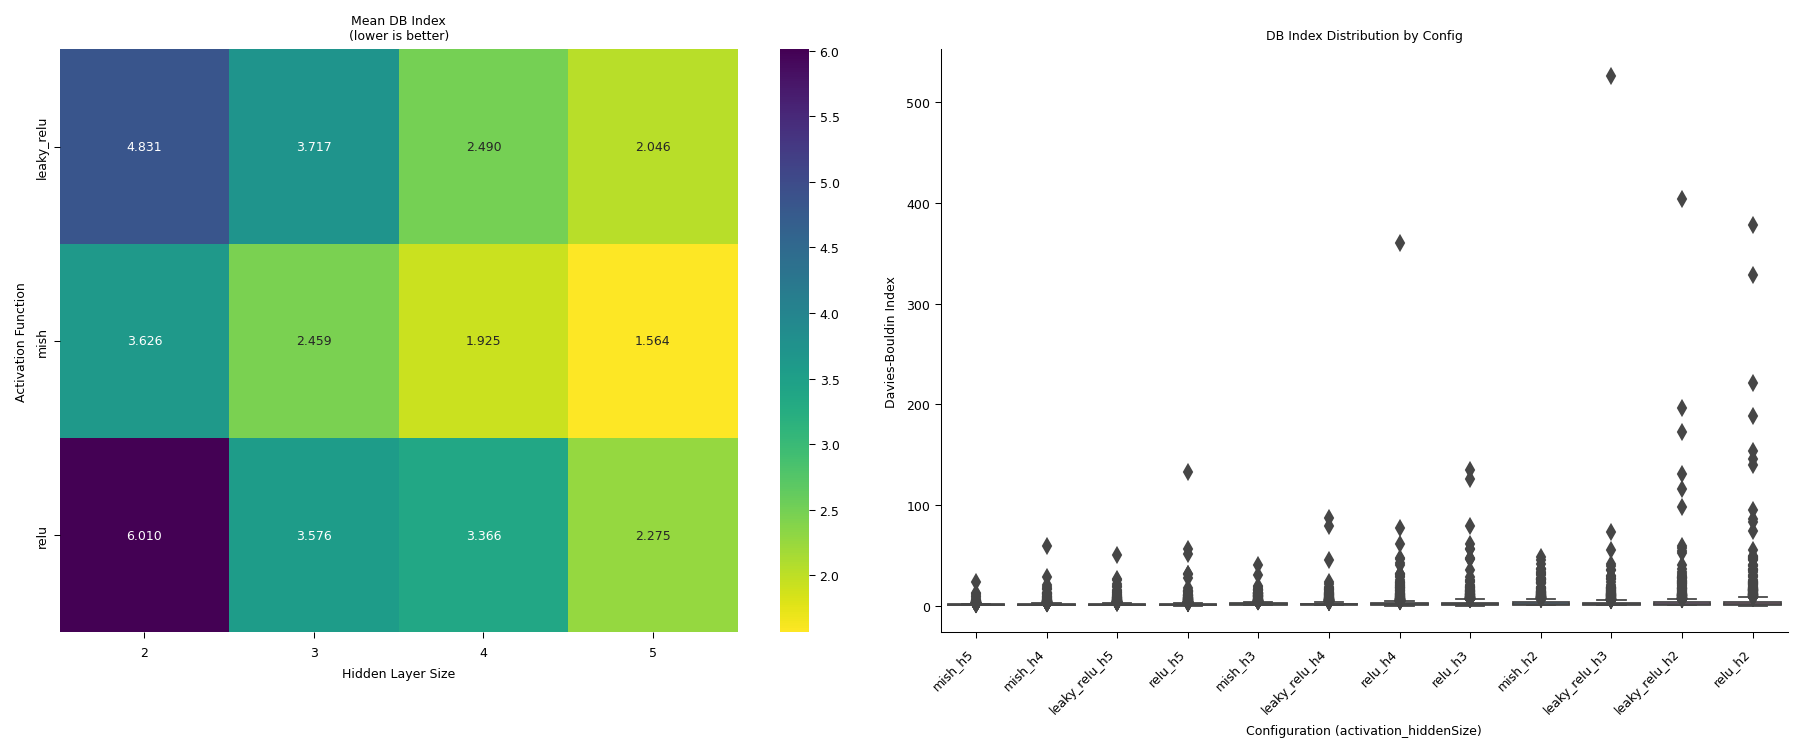


Summary: Mean DB Index by Configuration
                       db_index                            final_loss        
                           mean      std     min       max       mean     std
activation hidden_size                                                       
leaky_relu 2             4.8313  17.1770  0.6625  404.1982     0.0203  0.0008
           3             3.7169  17.2559  0.6352  526.0935     0.0196  0.0011
           4             2.4901   4.5220  0.6188   87.0746     0.0188  0.0013
           5             2.0457   2.6484  0.6666   50.3081     0.0179  0.0014
mish       2             3.6262   4.9986  0.7794   49.0671     0.0198  0.0008
           3             2.4590   2.7213  0.7698   41.0091     0.0188  0.0010
           4             1.9247   2.5920  0.7681   59.3949     0.0177  0.0011
           5             1.5642   1.1291  0.8009   23.7280     0.0169  0.0010
relu       2             6.0100  21.2952  0.0000  377.9899     0.0205  0.0008
           3           

In [30]:
# Visualize sweep results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: DB Index by activation and hidden size (heatmap of means)
pivot_db = sweep_results_df.groupby(['activation', 'hidden_size'])['db_index'].mean().unstack()
sns.heatmap(pivot_db, annot=True, fmt='.3f', cmap='viridis_r', ax=axes[0])
axes[0].set_title('Mean DB Index\n(lower is better)')
axes[0].set_xlabel('Hidden Layer Size')
axes[0].set_ylabel('Activation Function')

# Plot 2: Box plot of DB index distribution
sweep_results_df['config'] = sweep_results_df['activation'] + '_h' + sweep_results_df['hidden_size'].astype(str)
order = sweep_results_df.groupby('config')['db_index'].mean().sort_values().index
sns.boxplot(data=sweep_results_df, x='config', y='db_index', order=order, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title('DB Index Distribution by Config')
axes[1].set_xlabel('Configuration (activation_hiddenSize)')
axes[1].set_ylabel('Davies-Bouldin Index')

plt.tight_layout()
plt.savefig(f"sweep_results_{comparison}_{ensemble}.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSummary: Mean DB Index by Configuration")
summary = sweep_results_df.groupby(['activation', 'hidden_size']).agg({
    'db_index': ['mean', 'std', 'min', 'max'],
    'final_loss': ['mean', 'std']
}).round(4)
print(summary)

# Best configuration
best_idx = sweep_results_df.groupby(['activation', 'hidden_size'])['db_index'].mean().idxmin()
print(f"\nBest configuration: activation={best_idx[0]}, hidden_size={best_idx[1]}")

In [31]:
def resample_ensemble_stage_activity(class_matrix_store,
                                     n_frames_to_draw:int=500,
                                     ensemble:str = "",
                                     geno:str="",
                                     stages_to_resample:list  = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error'],
                                     **kwargs):
    '''To iterate over specified stages and return dict containing N resampled frame for each stage. Requires 'resample_into_class_matrix'
    '''
    ensemble_resample_in_phase_dict = {}
    for class_name in stages_to_resample: #store the versions for this bootstrap run
        class_mat = resample_into_class_matrix(class_matrix_store,n_frames_to_draw,ensemble, class_name, geno)
        ensemble_resample_in_phase_dict[class_name] = class_mat
        
    return ensemble_resample_in_phase_dict